# Understanding Transformers

## Creating simple array and printing the index and value
I am creating a simple words array and printing

In [ ]:
words = ["The", "cat", "drank", "milk"]

for position, word in enumerate(words):
    print(position, word)

0 Rajesh
1 likes
2 machine
3 learning


## Creating Vocabolary for the words 
I am assigning index to each word now and forming it as array 

In [1]:
vocab = {
    "The": 0,
    "cat": 1,
    "drank": 2,
    "milk": 3
}

sentence = ["The", "cat", "drank", "milk"]

encoded = [vocab[word] for word in sentence]

print(encoded)  

[0, 1, 2, 3]


## Using Embedding

Next step i create embeddings 


In [2]:
embeddings = {
    "cat": [0.2, 0.8, -0.3],
    "dog": [0.3, 0.7, -0.2],
    "milk": [-0.6, 0.1, 0.9]
}

print(embeddings["cat"])

[0.2, 0.8, -0.3]


### Calculate distance between embeddings

next i calculate the distance between embeddings

In [ ]:
import numpy as np

cat = np.array([0.2, 0.8, -0.3])
dog = np.array([0.3, 0.7, -0.2])

distance = np.linalg.norm(cat - dog) # linalg is a linear algebra module in numpy, and norm is a function that computes the Euclidean distance between two vectors.
# euclidean distance is the straight line distance between two points in Euclidean space. In this case, it is the distance between the embeddings of the words "cat" and "dog".
# euclidean distance is calculated as the square root of the sum of the squared differences between the corresponding elements of the two vectors. In this case, it is calculated as:
# sqrt((0.2 - 0.3)^2 + (0.8 - 0.7)^2 + (-0.3 - -0.2)^2) = sqrt(0.01 + 0.01 + 0.01) = sqrt(0.03) = 0.17320508075688773
print(distance)

0.17320508075688776


In [4]:
import numpy as np

sentence = np.array([
    [0.1, 0.2, 0.3],      # The
    [0.2, 0.8, -0.3],     # cat
    [0.5, -0.2, 0.4],     # drank
    [-0.6, 0.1, 0.9]      # milk
])

print(sentence.shape)

(4, 3)


In [5]:
import numpy as np

words = ["cat", "dog", "milk"]

embeddings = {
    "cat": np.array([0.2, 0.8, -0.3]),
    "dog": np.array([0.3, 0.7, -0.2]),
    "milk": np.array([-0.6, 0.1, 0.9])
}

for word in words:
    print(f"{word}: {embeddings[word]}")

cat: [ 0.2  0.8 -0.3]
dog: [ 0.3  0.7 -0.2]
milk: [-0.6  0.1  0.9]


In [6]:
import numpy as np

rajesh = np.array([1, 0, 1])
loves = np.array([0, 1, 1])
machine = np.array([1, 1, 0])
learning = np.array([1, 1, 1])

In [7]:
sentence = np.array([
    rajesh,
    loves,
    machine,
    learning
])

print(sentence)


[[1 0 1]
 [0 1 1]
 [1 1 0]
 [1 1 1]]


## Giving attention to the words 

In [ ]:
The     = 5
cat     = 20
chased  = 35
the     = 5
mouse   = 35

Words need a representation that contains meaning.

cat
dog
lion
tiger should be closer

Using embedding

Dimension 1 = animal-ness
Dimension 2 = vehicle-ness

In [8]:
cat = [0.8, 0.2]
dog = [0.9, 0.1]
car = [0.1, 0.9]

## Lets create 2d embedding

In [ ]:
The cat chased the mouse


In [9]:
cat   = [8,2]
chased= [5,5]
mouse = [7,3]

In [ ]:
cat-mouse= [1,-1]
distance = sqrt(1^2 + (-1)^2) = sqrt(2) = 1.414

cat - chased = [3,-3]
distance = sqrt(3^2 + (-3)^2) = sqrt(18) = 4.242

TypeError: unsupported operand type(s) for -: 'list' and 'list'

Distance(cat, mouse)  = 1.41
Distance(cat, chased) = 4.24

## Dot product

In [ ]:
chased.cat =[5,5].[8,2] = 5*8 + 5*2 = 40 + 10 = 50
chased.mouse =[5,5].[7,3] = 5*7 + 5*3 = 35 + 15 = 50


In [11]:
import numpy as np

chased = np.array([5, 5])

words = {
    "cat": np.array([8, 2]),
    "mouse": np.array([7, 3]),
    "the": np.array([1, 0])
}

for word, vector in words.items():
    score = np.dot(chased, vector)
    print(word, score)

cat 50
mouse 50
the 5


## Attention weights must sum to 1.

In [14]:
import numpy as np

chased = np.array([5, 5])

words = {
    "cat": np.array([8, 2]),
    "mouse": np.array([7, 3]),
    "the": np.array([1, 0])
}

 
 
score = [np.dot(chased, vector) for vector in words.values()]
score
attention = np.exp(score) / np.sum(np.exp(score))
attention

 

array([5.00000000e-01, 5.00000000e-01, 1.43125929e-20])

In [16]:
Q = [2, 3]

K1 = [1, 1]
K2 = [4, 2]
K3 = [0, 5]

In [20]:
score = [np.dot(Q, K1), np.dot(Q, K2), np.dot(Q, K3)]
exp_score = np.exp(score)
attention = exp_score / np.sum(exp_score)
attention

array([3.31889066e-05, 2.68932495e-01, 7.31034316e-01])

In [21]:
import numpy as np

attention = np.array([0.2, 0.3, 0.5])

V = np.array([
    [1, 2],  # V1
    [3, 4],  # V2
    [5, 6]   # V3
])

output = attention @ V

print(output)

[3.6 4.6]


In [30]:
import numpy as np

words = ["Rajesh", "loves", "machine", ]

embeddings = {
    "Rajesh":   np.array([4, 3]),
    "loves":    np.array([2, 1]),
    "machine":  np.array([2, 1]),
    "learning": np.array([4, 5])
}

query = embeddings["learning"]

scores = []

print("Dot Products")
print("-" * 20)

for word in words:
    score = np.dot(query, embeddings[word])
    scores.append(score)

    print(f"{word:10s} score = {score}")

scores = np.array(scores)

exp_scores = np.exp(scores - np.max(scores))
attention = exp_scores / exp_scores.sum()

print("\nAttention Weights")
print("-" * 20)
score = np.dot(query, embeddings[word]) / np.sqrt(len(query))
score
for word, weight in zip(words, attention):
    print(f"{word:10s} {weight:.10f}")

Dot Products
--------------------
Rajesh     score = 31
loves      score = 13
machine    score = 13

Attention Weights
--------------------
Rajesh     0.9999999695
loves      0.0000000152
machine    0.0000000152


### Using torch

In [17]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

words = ["Rajesh", "loves", "machine", "learning"]

embedding = nn.Embedding(
    num_embeddings=len(words),
    embedding_dim=4
).to(device)

word_to_id = {w: i for i, w in enumerate(words)}

sentence = torch.tensor(
    [
        word_to_id["Rajesh"],
        word_to_id["loves"],
        word_to_id["machine"],
        word_to_id["learning"],
    ],
    device=device,
)
print(sentence)
x = embedding(sentence)

 

embed_dim = 4
# This is a linear layer that will project the input embeddings into query, key, and value vectors. The bias is set to False because we don't want to add any additional bias term to the linear transformation. The output dimension of each linear layer is the same as the input embedding dimension (embed_dim), which is 4 in this case. The layers are moved to the specified device (CPU or GPU) for computation.
Wq = nn.Linear(embed_dim, embed_dim, bias=False).to(device)
Wk = nn.Linear(embed_dim, embed_dim, bias=False).to(device)
Wv = nn.Linear(embed_dim, embed_dim, bias=False).to(device)
 
Q = Wq(x)
K = Wk(x)
V = Wv(x)

print("Q")
print(Q)

print("\nK")
print(K)

print("\nV")
print(V)

tensor([0, 1, 2, 3], device='cuda:0')
Q
tensor([[-0.2601,  0.0719,  0.0653,  0.4875],
        [ 0.0016, -0.2398,  0.1006,  0.4026],
        [-0.0193, -0.9050, -1.4668,  0.2081],
        [ 0.2878, -0.2439, -0.1776, -0.0364]], device='cuda:0',
       grad_fn=<MmBackward0>)

K
tensor([[ 0.1894,  0.7720, -0.2139,  0.2553],
        [ 0.0178,  0.5275,  0.5984, -0.0274],
        [ 0.0366,  0.0856, -0.0062, -1.9116],
        [-0.1668, -0.1674, -0.3964, -0.2920]], device='cuda:0',
       grad_fn=<MmBackward0>)

V
tensor([[ 0.4606,  0.2350, -0.0720,  0.3648],
        [ 0.0042, -0.0538,  0.3840,  0.2884],
        [-0.6870, -1.4791,  1.1547, -0.0496],
        [-0.3134, -0.1497, -0.1770, -0.0287]], device='cuda:0',
       grad_fn=<MmBackward0>)


## Calculate scores

In [21]:
scores = Q @ K.T
attention_weights = torch.softmax(scores, dim=-1)

attention_weights

tensor([[0.3258, 0.3076, 0.1138, 0.2528],
        [0.2844, 0.2920, 0.1431, 0.2805],
        [0.2007, 0.0719, 0.1759, 0.5514],
        [0.2348, 0.2075, 0.2770, 0.2808]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [5]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Model:", torch.cuda.get_device_name(0))
print("Compute Capability:", torch.cuda.get_device_capability(0))

CUDA Available: True
GPU Model: NVIDIA GeForce RTX 5060 Laptop GPU
Compute Capability: (12, 0)


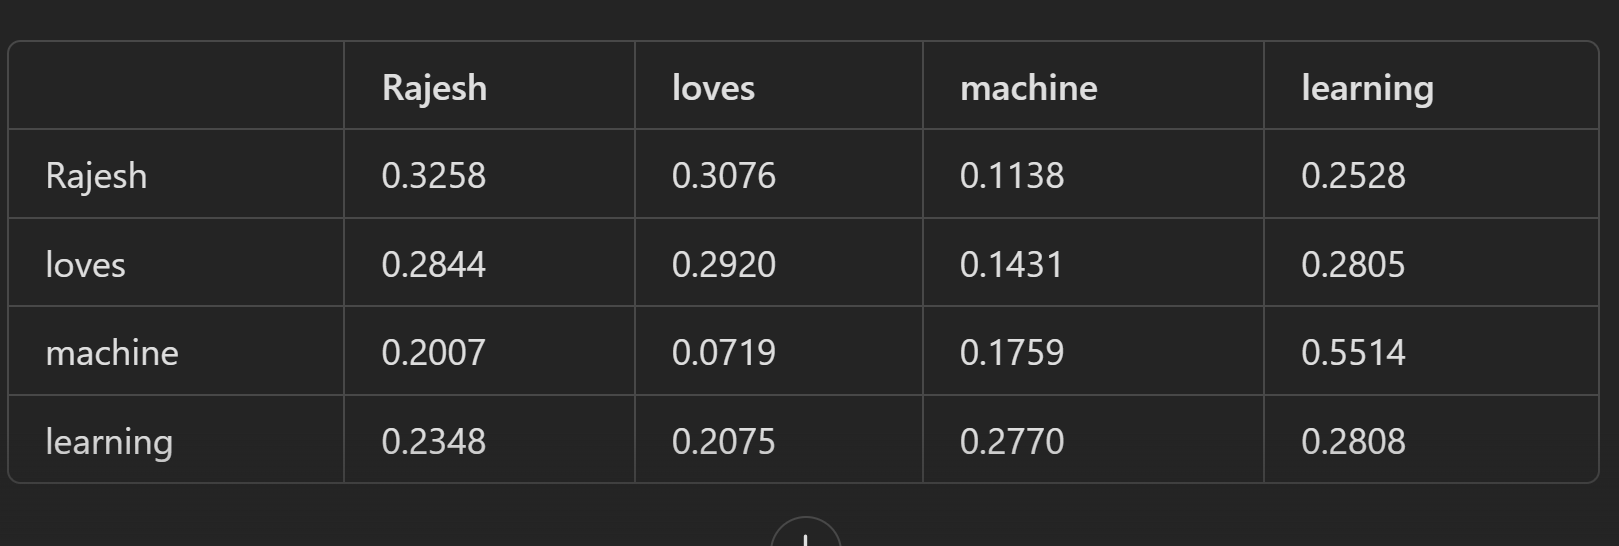

In [22]:
output = attention_weights @ V

output

tensor([[-0.0060, -0.1461,  0.1812,  0.1947],
        [-0.0540, -0.2025,  0.2072,  0.1728],
        [-0.2010, -0.2995,  0.1187,  0.0694],
        [-0.1693, -0.4077,  0.3329,  0.1237]], device='cuda:0',
       grad_fn=<MmBackward0>)

# complete code 

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

# -------------------------------------------------------------------
# 1. Real Sample Corpus (e.g., loaded from a file or dataset library)
# -------------------------------------------------------------------
corpus = [
    "Artificial intelligence is transforming technology across the globe",
    "Deep learning models require significant computational resources for training",
    "Machine learning algorithms extract hidden patterns from unstructured data",
    "Natural language processing allows computers to comprehend human speech",
    "Neural networks consist of interconnected nodes inspired by the human brain",
    "Nature is a source of inspiration for many machine learning algorithms",
]

# -------------------------------------------------------------------
# 2. Build Vocabulary with Special Tokens ([PAD], [UNK])
# -------------------------------------------------------------------
PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"

# Extract unique words
unique_words = sorted(set(" ".join(corpus).lower().split()))

# Reserve 0 for Padding
vocab = [PAD_TOKEN, UNK_TOKEN] + unique_words
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

PAD_IDX = word_to_id[PAD_TOKEN]
UNK_IDX = word_to_id[UNK_TOKEN]
VOCAB_SIZE = len(vocab)


# -------------------------------------------------------------------
# 3. PyTorch Custom Dataset
# -------------------------------------------------------------------
class TextDataset(Dataset):

    def __init__(self, text_list, word_to_id):
        self.samples = []
        for text in text_list:
            tokens = text.lower().split()
            if len(tokens) > 1:
                # Inputs = all tokens except last; Target = last token
                input_ids = [
                    word_to_id.get(w, UNK_IDX) for w in tokens[:-1]
                ]
                target_id = word_to_id.get(tokens[-1], UNK_IDX)
                self.samples.append(
                    (torch.tensor(input_ids), torch.tensor(target_id))
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# Custom collate_fn to dynamic-pad sequences in each batch
def collate_fn(batch):
    inputs, targets = zip(*batch)
    # Pad sequences to the longest sequence in the current batch
    padded_inputs = pad_sequence(
        inputs, batch_first=True, padding_value=PAD_IDX
    )
    targets = torch.stack(targets)
    return padded_inputs, targets


# Create DataLoader
dataset = TextDataset(corpus, word_to_id)
dataloader = DataLoader(
    dataset, batch_size=2, shuffle=True, collate_fn=collate_fn
)


# -------------------------------------------------------------------
# 4. Attention Model with Padding Mask Support
# -------------------------------------------------------------------
class TinyAttentionModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )

        self.Wq = nn.Linear(embed_dim, embed_dim, bias=False)
        self.Wk = nn.Linear(embed_dim, embed_dim, bias=False)
        self.Wv = nn.Linear(embed_dim, embed_dim, bias=False)

        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        # Create mask for padding tokens (True where token is [PAD])
        pad_mask = x == self.pad_idx  # Shape: (batch_size, seq_len)

        # Embeddings
        x_embed = self.embedding(x)

        # Q, K, V Projection
        Q = self.Wq(x_embed)
        K = self.Wk(x_embed)
        V = self.Wv(x_embed)

        # Scaled Dot-Product Attention
        scores = Q @ K.transpose(-2, -1) / (Q.size(-1) ** 0.5)

        # Apply padding mask: set attention scores for [PAD] tokens to -infinity
        if pad_mask.any():
            mask = pad_mask.unsqueeze(1).expand_as(scores)
            scores = scores.masked_fill(mask, float("-inf"))

        attention_weights = torch.softmax(scores, dim=-1)

        # Output aggregation
        output = attention_weights @ V

        # Mean pooling ignoring padding
        output = output.mean(dim=1)

        logits = self.fc(output)
        return logits, attention_weights


# -------------------------------------------------------------------
# 5. Training Loop
# -------------------------------------------------------------------
model = TinyAttentionModel(
    vocab_size=VOCAB_SIZE, embed_dim=16, pad_idx=PAD_IDX
)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    total_loss = 0
    for X_batch, Y_batch in dataloader:
        optimizer.zero_grad()
        logits, _ = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}, Loss = {total_loss/len(dataloader):.4f}")


# -------------------------------------------------------------------
# 6. Testing Inference
# -------------------------------------------------------------------
test_sentence = "Natur"
tokens = [word_to_id.get(w.lower(), UNK_IDX) for w in test_sentence.split()]
test_tensor = torch.tensor([tokens], dtype=torch.long)

model.eval()
with torch.no_grad():
    logits, _ = model(test_tensor)
    pred_id = logits.argmax(dim=1).item()
    print(f"\nInput: '{test_sentence}'")
    print(f"Predicted Next Word: '{id_to_word[pred_id]}'")

Epoch 25, Loss = 0.0052
Epoch 50, Loss = 0.0015
Epoch 75, Loss = 0.0009
Epoch 100, Loss = 0.0004

Input: 'Natur'
Predicted Next Word: 'brain'
